In [5]:
# ==========================================
# Imports
# ==========================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt

import joblib
import json
import time

In [6]:
# ==========================================
# Configuration
# ==========================================

DATA_PATH = Path("../data/processed/dev_sample.parquet")

RANDOM_STATE = 42

TEST_SIZE = 0.20

MODEL_NAME = "safestreet_rf_v2"

In [7]:
# ==========================================
# Load Development Dataset
# ==========================================

df = pd.read_parquet(DATA_PATH)

print(df.shape)

df.head()

(1000000, 10)


,Latitude,Longitude,Hour,DayOfWeek,Month,IsWeekend,District,Community Area,Location Description,RiskLevel
0,41.886303,-87.714765,15,4,12,0,11.0,27.0,"SCHOOL, PUBLIC, GROUNDS",High
1,41.666129,-87.620077,6,1,9,0,5.0,53.0,OTHER,Low
2,41.970281,-87.657655,6,4,8,0,20.0,3.0,APARTMENT,Low
3,41.814407,-87.642615,22,4,5,0,9.0,61.0,STREET,Low
4,41.764506,-87.645607,15,6,5,1,7.0,68.0,RESIDENCE,Medium


Feature Selection

In [8]:
# ==========================================
# Feature Selection
# ==========================================

FEATURES = [
    "Latitude",
    "Longitude",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "District",
    "Community Area",
    "Location Description",
]

TARGET = "RiskLevel"

X = df[FEATURES]
y = df[TARGET]

print("Feature Matrix :", X.shape)
print("Target Shape   :", y.shape)

Feature Matrix : (1000000, 9)
Target Shape   : (1000000,)


In [9]:
# ==========================================
# Detect Feature Types
# ==========================================

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object", "string"]
).columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['Location Description']

Numerical Features
['Latitude', 'Longitude', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'District', 'Community Area']


In [10]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (800000, 9)
Testing Set  : (200000, 9)


In [11]:
# ==========================================
# Verify Class Distribution
# ==========================================

print("Training Distribution")

print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print()

print("Testing Distribution")

print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training Distribution
RiskLevel
Low       58.53
High      29.61
Medium    11.87
Name: proportion, dtype: float64

Testing Distribution
RiskLevel
Low       58.53
High      29.61
Medium    11.87
Name: proportion, dtype: float64


In [12]:
# ==========================================
# Build Preprocessing Pipeline
# ==========================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Latitude', 'Longitude', 'Hour', 'DayOfWeek',
                                  'Month', 'IsWeekend', 'District',
                                  'Community Area']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Location Description'])])


In [13]:
# ==========================================
# Balanced Random Forest Pipeline
# ==========================================

balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced"
            ),
        ),
    ]
)

print(balanced_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Latitude', 'Longitude',
                                                   'Hour', 'DayOfWeek', 'Month',
                                                   'IsWeekend', 'District',
                                                   'Community Area']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
    

In [10]:
# ==========================================
# Train Balanced Random Forest
# ==========================================

import time

print("=" * 60)
print("Training Balanced Random Forest...")
print("=" * 60)

start_time = time.time()

balanced_model.fit(X_train, y_train)

end_time = time.time()

balanced_training_time = end_time - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time : {balanced_training_time:.2f} seconds")
print(f"Training Time : {balanced_training_time/60:.2f} minutes")

Training Balanced Random Forest...

Training Completed Successfully!
Training Time : 1670.52 seconds
Training Time : 27.84 minutes


In [11]:
# ==========================================
# Evaluate Balanced Random Forest
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

print("=" * 60)
print("Evaluating Balanced Random Forest...")
print("=" * 60)

# Predictions
y_pred_balanced = balanced_model.predict(X_test)

# Accuracy
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print(f"\nAccuracy : {balanced_accuracy:.4f}")
print(f"Accuracy : {balanced_accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_balanced))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_balanced))

Evaluating Balanced Random Forest...

Accuracy : 0.5542
Accuracy : 55.42%

Classification Report

              precision    recall  f1-score   support

        High       0.45      0.52      0.48     59211
         Low       0.68      0.63      0.65    117053
      Medium       0.27      0.26      0.27     23736

    accuracy                           0.55    200000
   macro avg       0.47      0.47      0.47    200000
weighted avg       0.56      0.55      0.56    200000


Confusion Matrix

[[30503 23969  4739]
 [30878 74077 12098]
 [ 5978 11495  6263]]


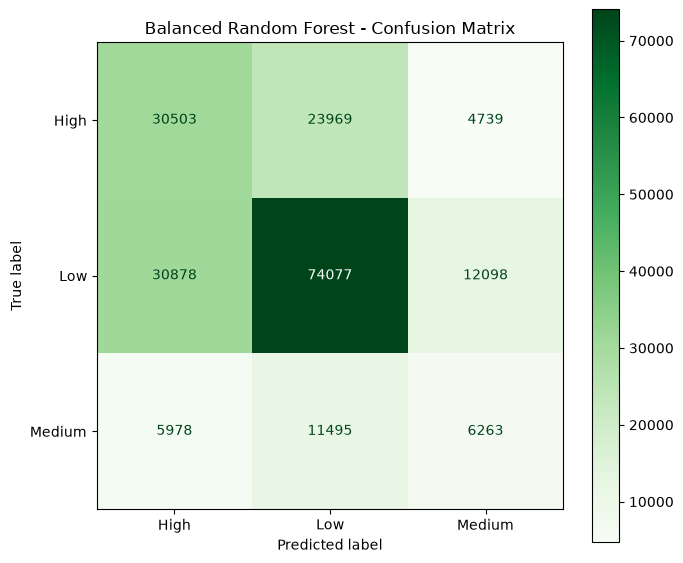

In [12]:
# ==========================================
# Balanced Model Confusion Matrix
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced,
    cmap="Greens",
    ax=ax
)

plt.title("Balanced Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# Baseline Results
# ==========================================

baseline_accuracy = 0.5964
baseline_training_time = 27.38   # minutes

In [16]:
# ==========================================
# Compare Models
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        balanced_accuracy
    ],
    "Training Time (min)": [
        baseline_training_time,
        round(balanced_training_time / 60, 2)
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

comparison

,Model,Accuracy,Training Time (min)
0,Baseline Random Forest,0.5964,27.38
1,Balanced Random Forest,0.5542,27.84


Experiment 2 - Tuned Random Forest

In [17]:
# ==========================================
# Tuned Random Forest Pipeline
# ==========================================

tuned_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

print(tuned_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Latitude', 'Longitude',
                                                   'Hour', 'DayOfWeek', 'Month',
                                                   'IsWeekend', 'District',
                                                   'Community Area']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
    

Train Tuned Random Forest

In [18]:
# ==========================================
# Train Tuned Random Forest
# ==========================================

import time

print("=" * 60)
print("Training Tuned Random Forest...")
print("=" * 60)

start_time = time.time()

tuned_model.fit(X_train, y_train)

end_time = time.time()

tuned_training_time = end_time - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time : {tuned_training_time:.2f} seconds")
print(f"Training Time : {tuned_training_time/60:.2f} minutes")

Training Tuned Random Forest...

Training Completed Successfully!
Training Time : 198.26 seconds
Training Time : 3.30 minutes


Evaluate Tuned Random Forest

In [19]:
# ==========================================
# Evaluate Tuned Random Forest
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

print("=" * 60)
print("Evaluating Tuned Random Forest...")
print("=" * 60)

# Predictions
y_pred_tuned = tuned_model.predict(X_test)

# Accuracy
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"\nAccuracy : {tuned_accuracy:.4f}")
print(f"Accuracy : {tuned_accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_tuned))

Evaluating Tuned Random Forest...

Accuracy : 0.6129
Accuracy : 61.29%

Classification Report

              precision    recall  f1-score   support

        High       0.59      0.21      0.31     59211
         Low       0.62      0.94      0.74    117053
      Medium       0.59      0.03      0.06     23736

    accuracy                           0.61    200000
   macro avg       0.60      0.39      0.37    200000
weighted avg       0.61      0.61      0.53    200000


Confusion Matrix

[[ 12305  46858     48]
 [  7076 109472    505]
 [  1426  21516    794]]


In [20]:
# ==========================================
# Compare All Experiments
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline RF",
        "Balanced RF",
        "Tuned RF"
    ],
    "Accuracy": [
        baseline_accuracy,
        balanced_accuracy,
        tuned_accuracy
    ],
    "Training Time (min)": [
        baseline_training_time,
        round(balanced_training_time / 60, 2),
        round(tuned_training_time / 60, 2)
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

comparison

,Model,Accuracy,Training Time (min)
0,Baseline RF,0.5964,27.38
1,Balanced RF,0.5542,27.84
2,Tuned RF,0.6129,3.30


Experiment 4 - XGBoost Classifier

In [21]:
try:
    import xgboost

    print("XGBoost Version:", xgboost.__version__)

except ImportError:
    print("XGBoost is NOT installed.")

XGBoost is NOT installed.


In [1]:
import xgboost

print(xgboost.__version__)

3.2.0


# ==========================================
# Experiment 4 - XGBoost
# ==========================================

In [2]:
# ==========================================
# Import XGBoost
# ==========================================

from xgboost import XGBClassifier

print("XGBoost Imported Successfully!")

XGBoost Imported Successfully!


In [13]:
# ==========================================
# XGBoost Pipeline
# ==========================================

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                n_estimators=300,
                max_depth=8,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                eval_metric="mlogloss",
            ),
        ),
    ]
)

print(xgb_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Latitude', 'Longitude',
                                                   'Hour', 'DayOfWeek', 'Month',
                                                   'IsWeekend', 'District',
                                                   'Community Area']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
    

Train XGBoost Model

In [15]:
# ==========================================
# Encode Target Labels for XGBoost
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class Mapping:")

for index, label in enumerate(label_encoder.classes_):
    print(f"{index} -> {label}")

Class Mapping:
0 -> High
1 -> Low
2 -> Medium


In [16]:
# ==========================================
# Train XGBoost Model
# ==========================================

import time

print("=" * 60)
print("Training XGBoost Model...")
print("=" * 60)

start_time = time.time()

xgb_model.fit(X_train, y_train_encoded)

end_time = time.time()

xgb_training_time = end_time - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time : {xgb_training_time:.2f} seconds")
print(f"Training Time : {xgb_training_time/60:.2f} minutes")

Training XGBoost Model...

Training Completed Successfully!
Training Time : 18.96 seconds
Training Time : 0.32 minutes


In [17]:
# ==========================================
# Evaluate XGBoost Model
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

print("=" * 60)
print("Evaluating XGBoost Model...")
print("=" * 60)

# Predict encoded labels
y_pred_encoded = xgb_model.predict(X_test)

# Convert predictions back to original labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy : {xgb_accuracy:.4f}")
print(f"Accuracy : {xgb_accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Evaluating XGBoost Model...

Accuracy : 0.6227
Accuracy : 62.27%

Classification Report

              precision    recall  f1-score   support

        High       0.57      0.32      0.41     59211
         Low       0.64      0.88      0.74    117053
      Medium       0.56      0.08      0.15     23736

    accuracy                           0.62    200000
   macro avg       0.59      0.43      0.43    200000
weighted avg       0.61      0.62      0.57    200000


Confusion Matrix

[[ 19204  39794    213]
 [ 12333 103362   1358]
 [  2407  19349   1980]]


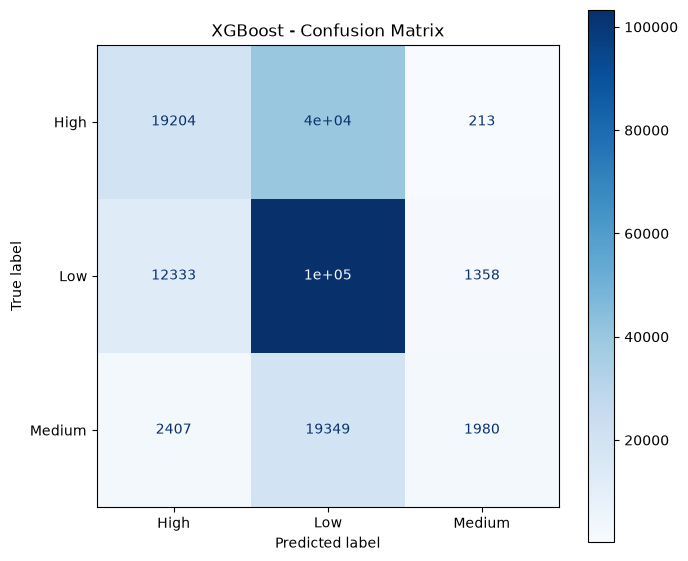

In [18]:
# ==========================================
# XGBoost Confusion Matrix
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax
)

plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# Save XGBoost Model
# ==========================================

from pathlib import Path
import joblib

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "safestreet_xgboost_v1.joblib"

joblib.dump(xgb_model, model_path)

print("Model saved successfully!")
print(model_path.resolve())

Model saved successfully!
D:\SOUMIT MANNA\IEM\Internship\Summer Internship\SafeStreet\ml_backend\saved_models\safestreet_xgboost_v1.joblib


In [1]:
try:
    import catboost
    print("CatBoost Version:", catboost.__version__)
except ImportError:
    print("CatBoost is NOT installed.")

CatBoost is NOT installed.


In [2]:
import catboost

print(catboost.__version__)

1.2.10


In [3]:
# ==========================================
# Import CatBoost
# ==========================================

from catboost import CatBoostClassifier

print("CatBoost Imported Successfully!")

CatBoost Imported Successfully!


In [14]:
# ==========================================
# CatBoost Pipeline
# ==========================================

catboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            CatBoostClassifier(
                iterations=300,
                depth=8,
                learning_rate=0.1,
                loss_function="MultiClass",
                random_seed=RANDOM_STATE,
                verbose=0,
            ),
        ),
    ]
)

print(catboost_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Latitude', 'Longitude',
                                                   'Hour', 'DayOfWeek', 'Month',
                                                   'IsWeekend', 'District',
                                                   'Community Area']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
    

Train CatBoost Model

In [15]:
# ==========================================
# Train CatBoost Model
# ==========================================

import time

print("=" * 60)
print("Training CatBoost Model...")
print("=" * 60)

start_time = time.time()

catboost_model.fit(X_train, y_train)

end_time = time.time()

catboost_training_time = end_time - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time : {catboost_training_time:.2f} seconds")
print(f"Training Time : {catboost_training_time/60:.2f} minutes")

Training CatBoost Model...

Training Completed Successfully!
Training Time : 39.30 seconds
Training Time : 0.66 minutes


In [16]:
# ==========================================
# Evaluate CatBoost Model
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

print("=" * 60)
print("Evaluating CatBoost Model...")
print("=" * 60)

# Predictions
y_pred_cat = catboost_model.predict(X_test)

# Flatten predictions if needed
import numpy as np
y_pred_cat = np.array(y_pred_cat).ravel()

# Accuracy
cat_accuracy = accuracy_score(y_test, y_pred_cat)

print(f"\nAccuracy : {cat_accuracy:.4f}")
print(f"Accuracy : {cat_accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_cat))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_cat))

Evaluating CatBoost Model...

Accuracy : 0.6201
Accuracy : 62.01%

Classification Report

              precision    recall  f1-score   support

        High       0.56      0.31      0.40     59211
         Low       0.63      0.89      0.74    117053
      Medium       0.57      0.08      0.13     23736

    accuracy                           0.62    200000
   macro avg       0.59      0.42      0.42    200000
weighted avg       0.60      0.62      0.57    200000


Confusion Matrix

[[ 18135  40929    147]
 [ 11740 104098   1215]
 [  2273  19681   1782]]


In [17]:
# ==========================================
# Save CatBoost Model
# ==========================================

from pathlib import Path
import joblib

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(exist_ok=True)

catboost_model_path = MODEL_DIR / "safestreet_catboost_v1.joblib"

joblib.dump(catboost_model, catboost_model_path)

print("CatBoost model saved successfully!")
print(catboost_model_path.resolve())

CatBoost model saved successfully!
D:\SOUMIT MANNA\IEM\Internship\Summer Internship\SafeStreet\ml_backend\saved_models\safestreet_catboost_v1.joblib
